# Forecast check plot

## Setup

In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

In [9]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = False 
plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = 'Helvetica'

## Categorical forecast plots

The categorical plotting functionality has been integrated into epymodelingsuite. You can use these functions directly in notebooks for more flexible plotting.

### Multi-horizon plot

This creates a single figure with all 4 horizons stacked vertically, sharing the x-axis.

In [11]:
# Load forecast file
forecast_file_path = "~/Developer/epymodelingsuite__categorical-plot/2026-01-10-MOBS-EpyStrain_Flu.csv"

In [12]:
from epymodelingsuite.visualization.core import plot_categorical_stacked_bars_multihorizon
from epymodelingsuite.utils.location import convert_location_name_format
from datetime import date

# Load FluSight format CSV
df_forecast = pd.read_csv(forecast_file_path, dtype={'location': str})
df_forecast['target_end_date'] = pd.to_datetime(df_forecast['target_end_date'])

# Filter for rate-trend categorical forecasts
df_rate_trends = df_forecast[
    (df_forecast["target"] == "wk flu hosp rate change") & 
    (df_forecast["output_type"] == "pmf")
]

# Remove territories for consistency
df_rate_trends = df_rate_trends[~df_rate_trends['location'].isin(["72", "78"])]

# Convert FIPS codes to state names
df_rate_trends = df_rate_trends.copy()
df_rate_trends["location"] = df_rate_trends["location"].apply(
    lambda x: convert_location_name_format(x, output_format="name")
)

# Define category labels for prettier legend
category_labels = {
    "large_decrease": "Large Decrease",
    "decrease": "Decrease",
    "stable": "Stable",
    "increase": "Increase",
    "large_increase": "Large Increase",
}

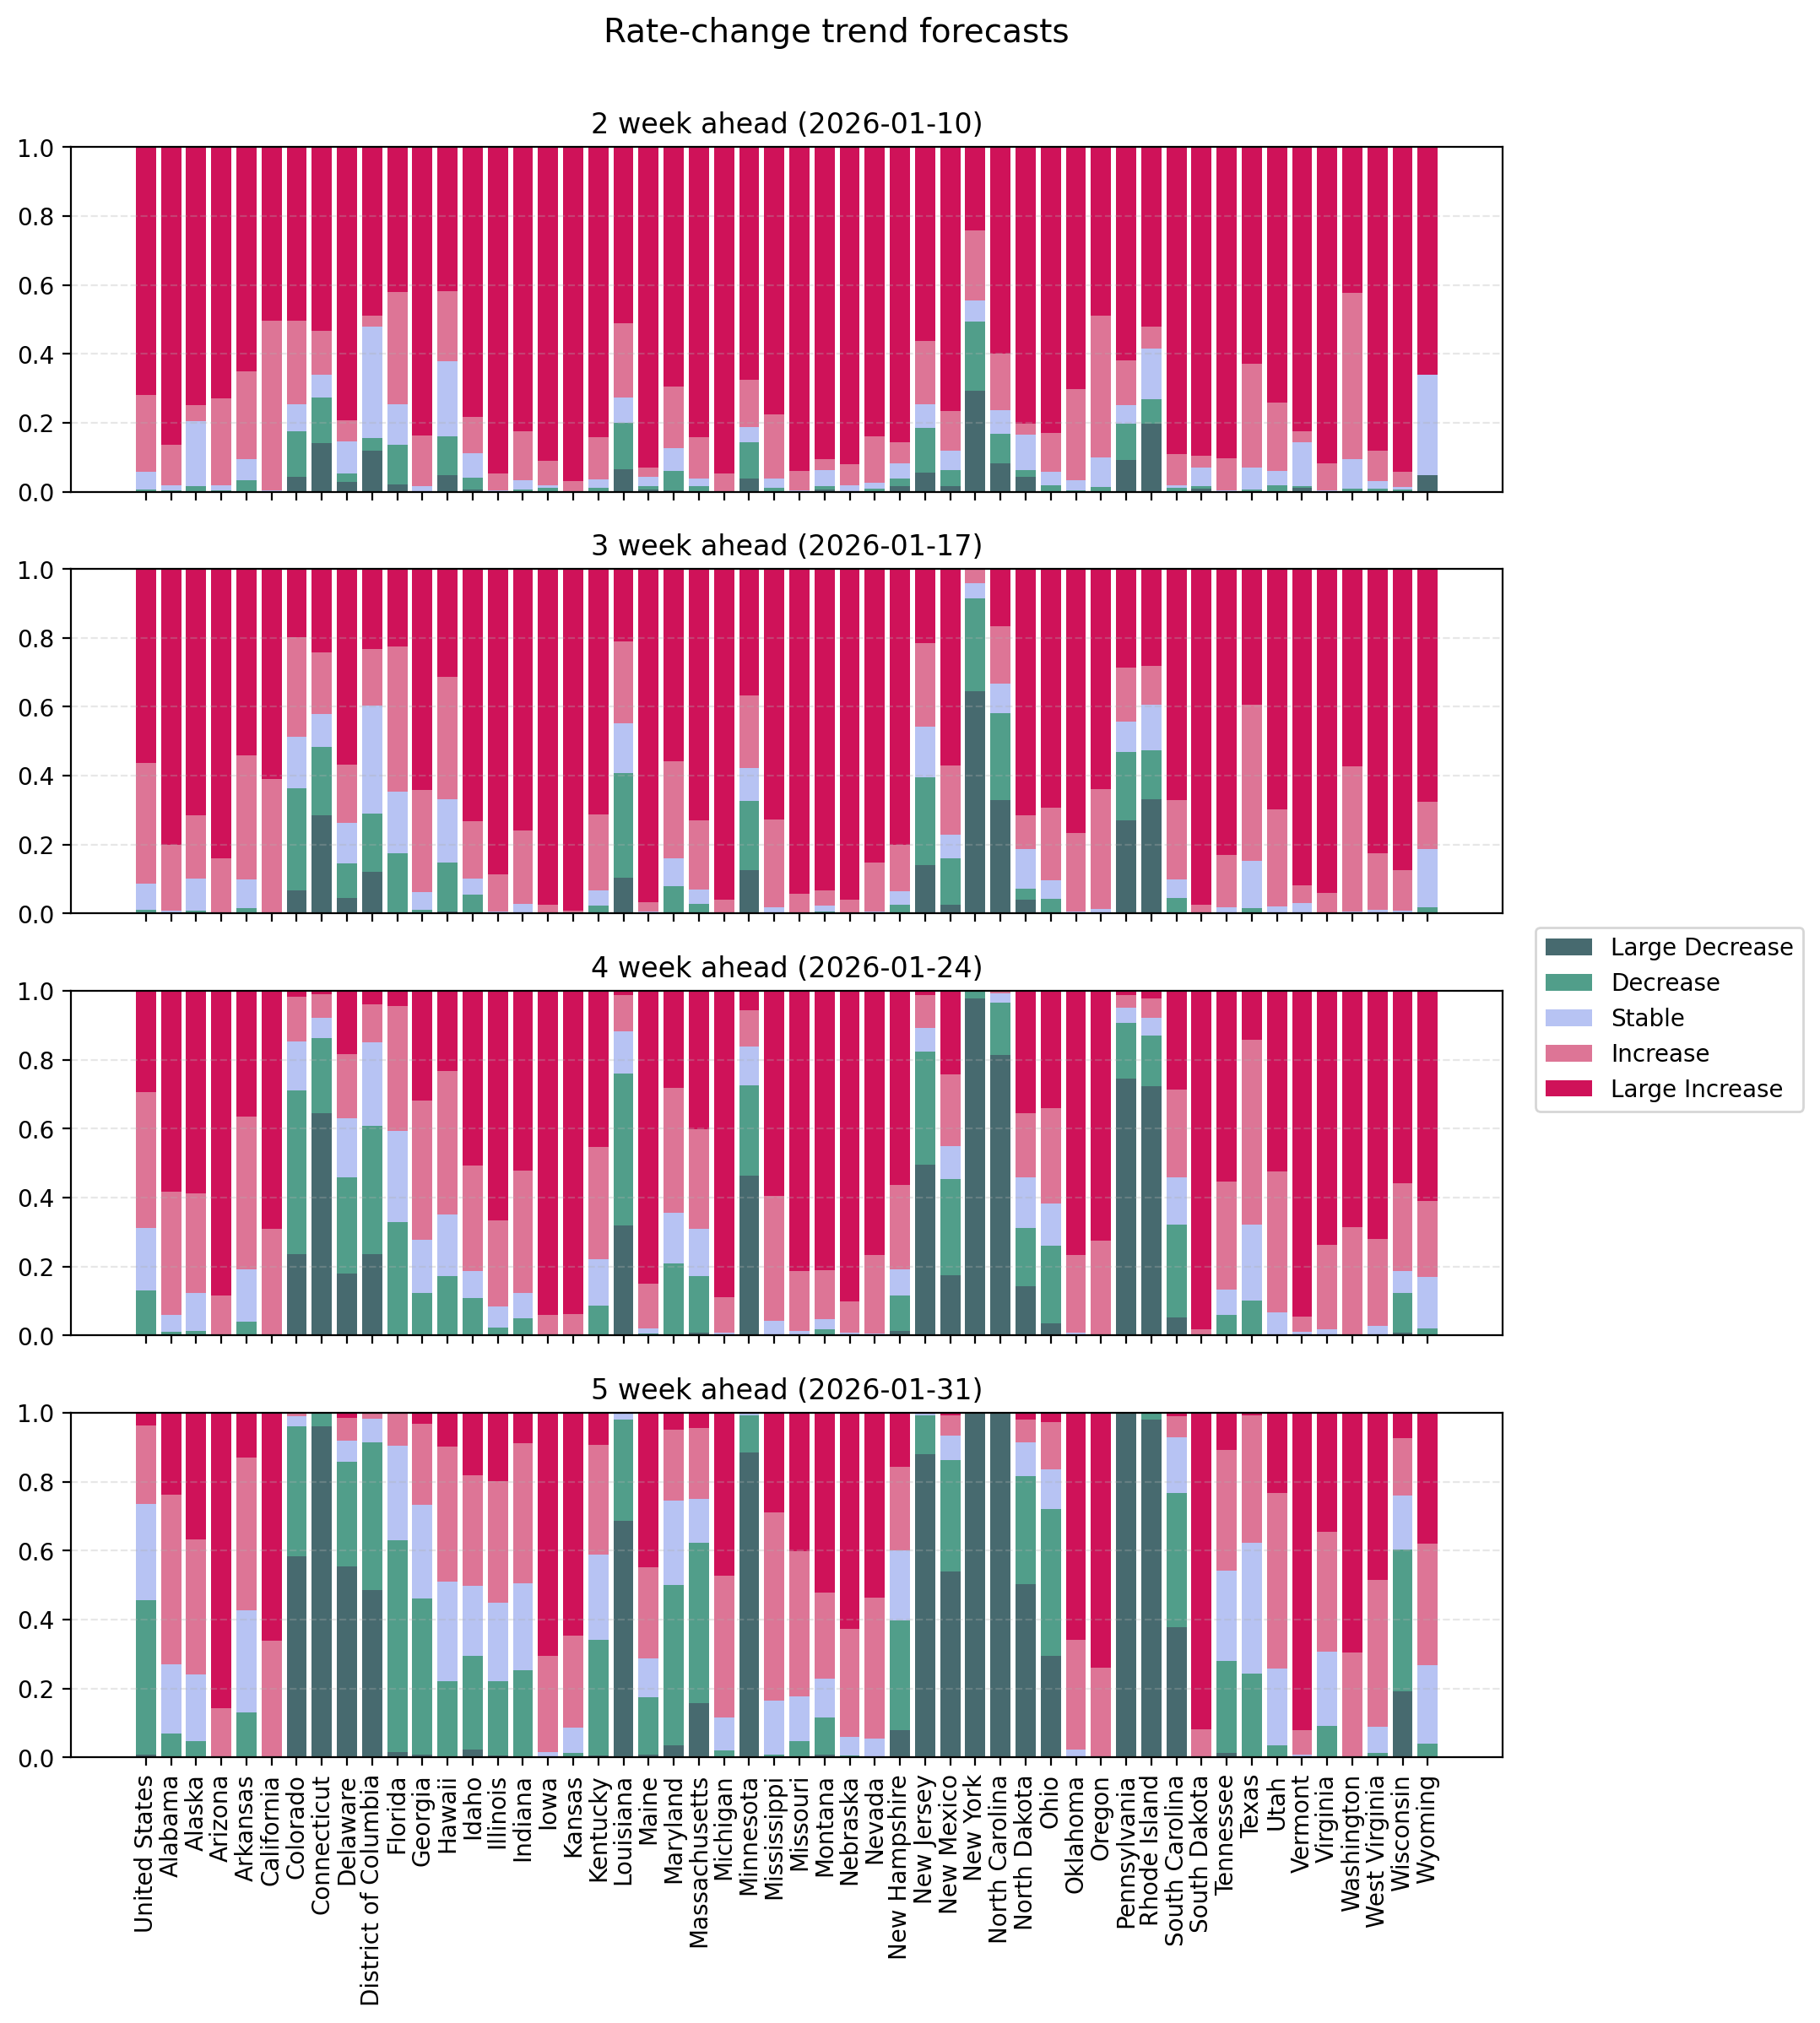

In [15]:
# Create the multi-horizon plot
fig, axes = plot_categorical_stacked_bars_multihorizon(
    df_categorical=df_rate_trends,
    categories=["large_decrease", "decrease", "stable", "increase", "large_increase"],
    colors=["#476a6f", "#519e8a", "#b7c3f3", "#dd7596", "#cf1259"],
    horizons=[0, 1, 2, 3],
    figsize=None,  # Defaults to (10, 3 * n_horizons)
    reference_date=date(2025, 11, 26),  # Optional, for panel titles
    category_labels=category_labels,  # Optional, for prettier legend labels
)

fig
plt.show()

# Save if desired
# fig.savefig(f"~/Downloads/{epiweek}_categorical_multihorizon.pdf", bbox_inches="tight")

### Single horizon plot

If you only want to plot one specific horizon:

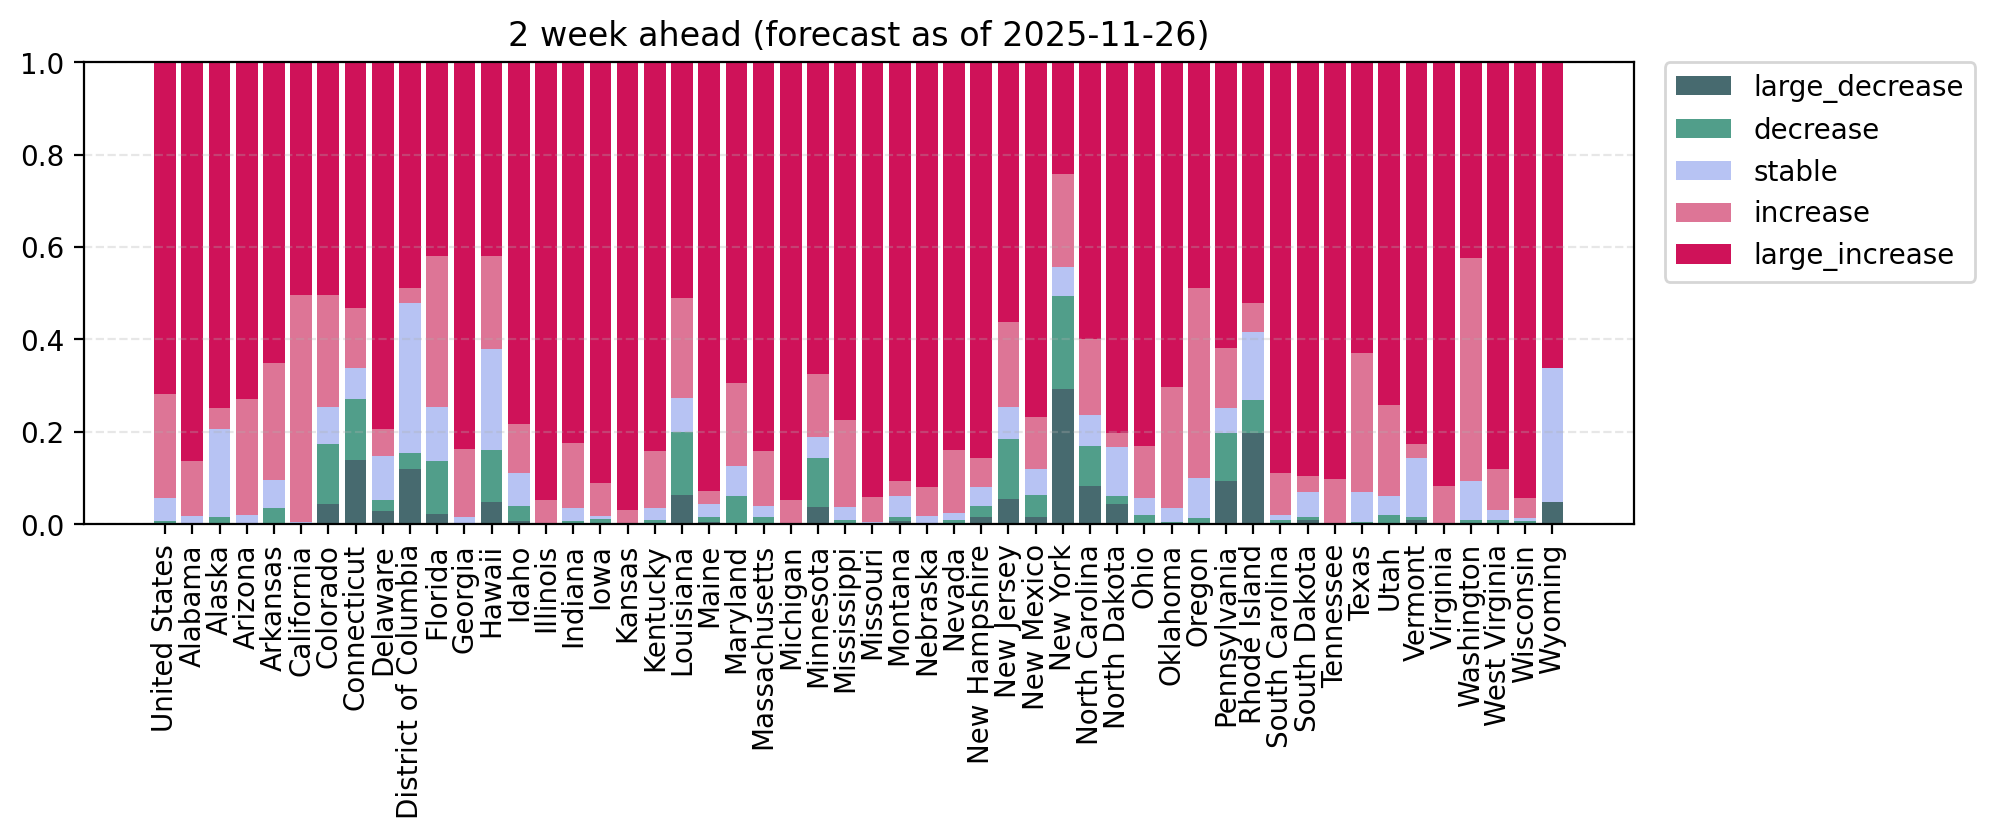

In [16]:
from epymodelingsuite.visualization.core import plot_categorical_stacked_bars

# Filter for single horizon (e.g., horizon 0 = 2 weeks ahead)
df_horizon_0 = df_rate_trends[df_rate_trends["horizon"] == 0]

fig_single, ax_single = plot_categorical_stacked_bars(
    df_categorical=df_horizon_0,
    categories=["large_decrease", "decrease", "stable", "increase", "large_increase"],
    colors=["#476a6f", "#519e8a", "#b7c3f3", "#dd7596", "#cf1259"],
    title="2 week ahead (forecast as of 2025-11-26)",
)

fig_single
plt.show()

---

## Archive: Old Manual Plotting Functions

The functions below were used before the categorical plotting functionality was integrated into epymodelingsuite. They are kept here for reference and backward compatibility.

### Old plotting function definitions

In [ ]:
def create_check_forecast_plots(
    forecast_file_path: str,
    surveillance_file_path: str,
    locations_file_path: str,
    forecast_date: str,
    start_date: str,
    output_figure_path: str | None = None,
    surveillance_value_column: str = 'hospitalizations',
    credible_interval: int = 90,
    log: bool = False
) -> tuple[plt.Figure, np.ndarray]:
    """
    Create forecast check plots for COVID/flu hospitalizations by state.

    Parameters
    ----------
    forecast_file_path : str
        Path to the forecast CSV file.
    surveillance_file_path : str
        Path to the surveillance data CSV file.
    locations_file_path : str
        Path to the locations CSV file containing location codes and names.
    forecast_date : str
        Date of the forecast (used in plot title).
    start_date : str
        Start date for filtering surveillance data.
    output_figure_path : str or None, optional
        Path to save the output figure. If None, figure is not saved, by default None.
    surveillance_value_column : str, optional
        Column name in surveillance data to use as values, by default 'hospitalizations'.
    credible_interval : int, optional
        Credible interval percentage for forecast uncertainty bands, by default 90.
    log : bool, optional
        Whether to use logarithmic scale for y-axis, by default False.

    Returns
    -------
    tuple[plt.Figure, np.ndarray]
        A tuple containing the matplotlib Figure and array of Axes objects.
    """
    # Load locations and build mapping to human-readable state names
    df_locations = pd.read_csv(locations_file_path)
    df_locations['state_name'] = df_locations['location_name'].apply(lambda key: " ".join(key.split(" ")))
    loc2state_name = dict(df_locations[['location','state_name']].drop_duplicates().values)
    loc2state_name['US'] = 'US'

    # Load forecasts
    df_forecast = pd.read_csv(forecast_file_path,dtype={'location':str})
    df_forecast['state_name'] = df_forecast['location'].apply(lambda key: loc2state_name[key])
    df_forecast['target_end_date'] = pd.to_datetime(df_forecast['target_end_date'])
    df_forecast = df_forecast[df_forecast.target=='wk inc flu hosp']
    df_forecast = df_forecast.astype({'output_type_id': float, 'value': float})

    # Load surveillance
    df_surveillance = pd.read_csv(surveillance_file_path)
    df_surveillance['target_end_date'] = pd.to_datetime(df_surveillance['target_end_date'])
    df_surveillance['values'] = df_surveillance[surveillance_value_column].copy()

    # Get list of states to plot (excluding territories)
    state_list = sorted(df_forecast.location.unique())
    state_list = [s for s in state_list if s not in ["72","78"]]

    # Set up figure
    fig, ax = plt.subplots(13,4,figsize = (20,2.5*13))
    fig.suptitle("Weekly Flu Hospitalizations (forecast as of %s)" % forecast_date, fontsize = 22, y = 1)

    # Calculate quantiles from credible interval
    lower_cri_quantile = (100 - credible_interval)/2/100
    upper_cri_quantile = 1 - lower_cri_quantile


    row = 0
    col = 0
    
    for state in state_list:

        if col == 4:
            col = 0
            row += 1

        # Plot surveillance data
        df_state_surveillance = df_surveillance[df_surveillance.location_code == state].copy()
        df_state_surveillance = df_state_surveillance.sort_values(by="target_end_date")
        df_state_surveillance = df_state_surveillance[df_state_surveillance.target_end_date >= start_date]

        date, values = zip(*df_state_surveillance[['target_end_date','values']].values)
        ax[row,col].plot(date,values,"ko-", label = "in sample")

        # Plot forecast
        df_state_forecast = df_forecast[df_forecast.location==state]

        if df_state_forecast.shape[0]!=0:

            meds = df_state_forecast[df_state_forecast['output_type_id']==0.5].sort_values(by = "target_end_date")
            lower_iqr = df_state_forecast[df_state_forecast['output_type_id']==0.25].sort_values(by = "target_end_date")
            upper_iqr = df_state_forecast[df_state_forecast['output_type_id']==0.75].sort_values(by = "target_end_date")
            lower_cri = df_state_forecast[df_state_forecast['output_type_id']==lower_cri_quantile].sort_values(by = "target_end_date")
            upper_cri = df_state_forecast[df_state_forecast['output_type_id']==upper_cri_quantile].sort_values(by = "target_end_date")

            date_runs = meds.target_end_date.values

            ax[row,col].plot(date_runs,meds['value'].values,"o-",color ="#4ECED4", label = "Median")
            ax[row,col].fill_between(date_runs,lower_iqr['value'].values,upper_iqr['value'].values,alpha = 0.25,color ="#4ECED4", label = "IQR")
            ax[row,col].fill_between(date_runs,lower_cri['value'].values,upper_cri['value'].values,alpha = 0.2,color ="#4ECED4",label=f"{int(credible_interval)}% CI")

            if log:
                ax[row,col].set_yscale("log")

        # Plot out of sample points
        out_sample = sorted(list(set(date).intersection(set([pd.to_datetime(d) for d in date_runs]))))
        df_out = df_state_surveillance[df_state_surveillance.target_end_date.isin(out_sample)]
        if df_out.shape[0]!=0:
            date, values = zip(*df_out[['target_end_date','values']].values)
            ax[row,col].plot(date,values,"ko-", mfc="white", label = "out of sample",zorder=100)

        # Format axes
        ticks = ax[row,col].get_xticks()
        ax[row,col].set_xticks(ticks)
        ax[row,col].set_xticklabels(ticks,rotation = 45)
        ax[row,col].xaxis.set_major_formatter(mdates.DateFormatter('%-y/%-m/%-d'))
        ax[row,col].set_title(loc2state_name[state], fontsize = 18)

        if col==0:
            ax[row,col].legend()
        col += 1
    plt.tight_layout()

    if output_figure_path is not None:
        plt.savefig(output_figure_path, bbox_inches="tight")
    plt.close()

    return fig, ax

In [ ]:
def create_check_categorical_targets_plots(
    forecast_file_path: str,
    locations_file_path: str,
    forecast_date: str,
    output_figure_path: str | None = None
) -> tuple[list[plt.Figure], list[plt.Axes]]:
    """
    Create stacked bar plots for categorical forecast targets by state.

    Parameters
    ----------
    forecast_file_path : str
        Path to the forecast CSV file.
    locations_file_path : str
        Path to the locations CSV file containing location codes and names.
    forecast_date : str
        Date of the forecast (used in plot title).
    output_figure_path : str or None, optional
        Path template to save output figures. Must contain '%i' for week ahead number.
        If None, figures are not saved, by default None.

    Returns
    -------
    tuple[list[plt.Figure], list[plt.Axes]]
        A tuple containing lists of matplotlib Figures and Axes objects for each horizon.
    """
    # Load locations and build mapping to human-readable state names
    df_locations = pd.read_csv(locations_file_path)
    df_locations['state_name'] = df_locations['location_name'].apply(
        lambda key: " ".join(key.split(" "))
    )
    loc2state_name = dict(df_locations[['location', 'state_name']].drop_duplicates().values)
    loc2state_name['US'] = 'US'

    # Load forecasts
    df_forecast = pd.read_csv(forecast_file_path, dtype={'location': str})
    df_forecast['state_name'] = df_forecast['location'].apply(lambda key: loc2state_name[key])
    df_forecast['target_end_date'] = pd.to_datetime(df_forecast['target_end_date'])

    # Filter to categorical target and remove territories for consistency
    df_categorical = df_forecast[df_forecast['target'] == "wk flu hosp rate change"].copy()
    df_categorical = df_categorical[~df_categorical['location'].isin(["72", "78"])]

    figs, axs = [], []

    # Plot per horizon
    for horizon, df_horizon in df_categorical.groupby('horizon'):

        fig, ax = plt.subplots(figsize=(10, 4))

        x_ordered = ['large_decrease', 'decrease', 'stable', 'increase', 'large_increase']
        states = sorted(df_horizon['state_name'].unique())
        x = range(len(states))
        total_y = np.zeros(len(states))
        colors = ["#476a6f", "#519e8a", "#b7c3f3", "#dd7596", "#cf1259"]

        for i, stack in enumerate(x_ordered):
            vals = []
            for s in states:
                df_tmp = df_horizon[(df_horizon['state_name'] == s) & (df_horizon['output_type_id'] == stack)]
                if df_tmp.shape[0] != 0:
                    vals.append(df_tmp['value'].values[0])
                else:
                    vals.append(0)
            y = np.array(vals)

            if i == 0:
                ax.bar(x, y, color=colors[i], width=0.9, label=stack)
            else:
                ax.bar(x, y, color=colors[i], bottom=total_y, width=0.9, label=stack)

            total_y += y

        ax.set_xticks(list(x))
        ax.set_xticklabels(states, rotation=90)
        ax.legend(loc='right')

        week_ahead = horizon + 2
        target_end_date = pd.to_datetime(df_horizon['target_end_date'].unique()[0])

        ax.set_title(
            "%i week ahead (%s, forecast as of %s)" %
            (week_ahead, target_end_date.strftime("%Y-%m-%d"), forecast_date),
            fontsize=16
        )

        plt.tight_layout()
        if output_figure_path is not None:
            plt.savefig(output_figure_path % week_ahead, bbox_inches="tight")
        plt.close(fig)

        figs.append(fig)
        axs.append(ax)

    return figs, axs

### Old example usage

For location file, use the following data:  
https://github.com/cdcepi/FluSight-forecast-hub/blob/main/auxiliary-data/locations.csv

In [ ]:
# Load files
forecast_file_path = "/home/minami/Developer/epymodelingsuite__categorical-plot/2026-01-10-MOBS-EpyStrain_Flu.csv"
surveillance_file_path = "~/Downloads/flu_hosp_25_202548.csv"
locations_file_path = "~/Downloads/locations.csv"

# Variables
forecast_date = "2025-11-26"
plot_start_date = "2025-09-01"
epiweek = "202548"

# Output paths
# Set to None not to export files
forecast_check_figure_path = None #f"~/Downloads/{epiweek}_flu_hosp_forecast_check.pdf"
categorical_targets_figure_path = None #f"~/Downloads/{epiweek}_flu_hosp_categorical_target_%iWahead.pdf"

In [ ]:
fig_forecast, ax_forecast = create_check_forecast_plots(
    forecast_file_path,
    surveillance_file_path,
    locations_file_path,
    forecast_date=forecast_date,
    start_date=plot_start_date,
    output_figure_path=forecast_check_figure_path,
    log=False
)

In [ ]:
fig_forecast

In [ ]:
figs_categorical, axs_categorical = create_check_categorical_targets_plots(
    forecast_file_path=forecast_file_path,
    locations_file_path=locations_file_path,
    forecast_date=forecast_date,
    output_figure_path=categorical_targets_figure_path
)

In [ ]:
for fig_categorical in figs_categorical:
    display(fig_categorical)